In [795]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import geometry
import mutation
import plotting
import set_ops
import core

importlib.reload(core)
importlib.reload(geometry)
importlib.reload(mutation)
importlib.reload(plotting)
importlib.reload(set_ops);

## Test Case: Polygon with holes

<Axes: >

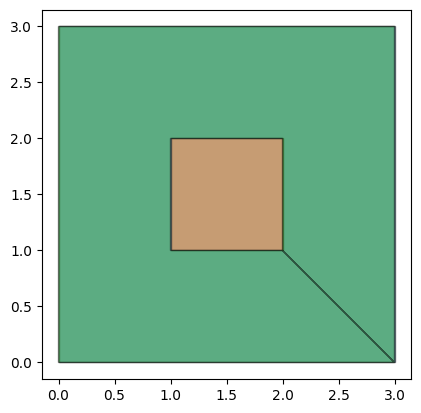

In [796]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)

p3 = set_ops.difference(p1, p2)

fig, ax = plt.subplots()
p1.plot(ax)
p2.plot(ax)
p3.plot(ax)

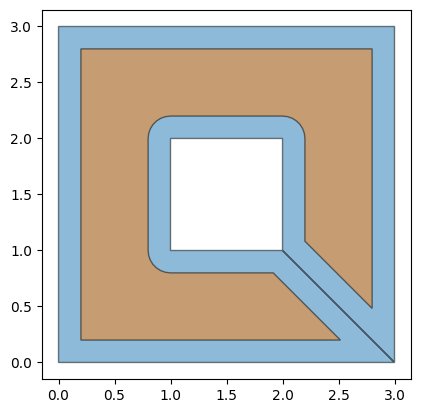

In [797]:
p4 = mutation.buffer(p3, -0.2)
fig, ax = plt.subplots()
p3.plot(ax=ax)
p4.plot(ax=ax);

## Test Case: L shape.

In [798]:
def create_L_shape(origin_x=0.0, origin_y=0.0):
    vertices = jnp.array(
        [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
        dtype=jnp.float32,
    )
    vertices = vertices + jnp.array([origin_x, origin_y])
    return geometry.Polygon(vertices=vertices)

0.5650695
False


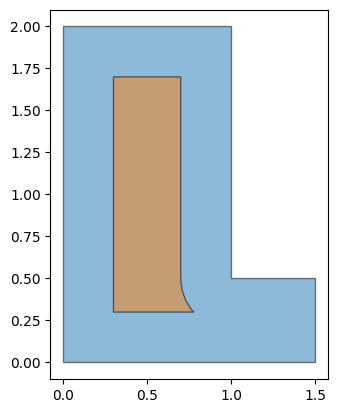

In [799]:
p1 = create_L_shape()
p2 = mutation.buffer(p1, -0.3)
fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax)
print(p2.area)
print(p2.self_intersect)

## Test Case: Square + Circle

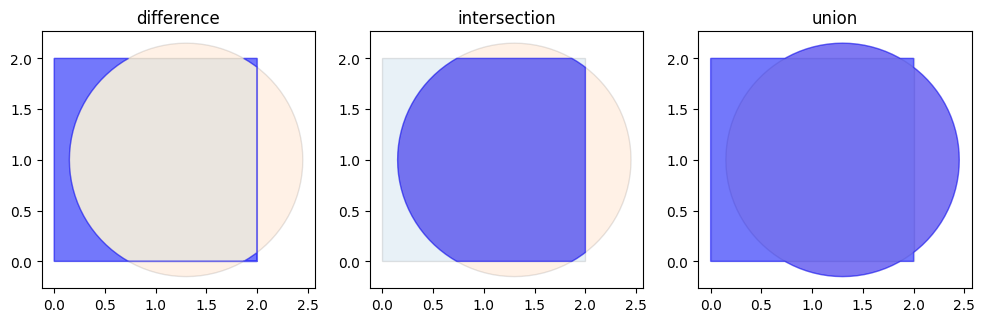

In [800]:
p1 = geometry.Rectangle(0.0, 0.0, 2.0, 2.0)
p2 = geometry.Circle(1.3, 1.0, 1.15, num_edges=100)

diff_poly = set_ops.difference(p1, p2)
intersection_poly = set_ops.intersection(p1, p2)
union_poly = set_ops.union(p1, p2)

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect('equal')
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color='blue')
ax[0].set_title('difference')
intersection_poly.plot(ax[1], color='blue')
ax[1].set_title('intersection')
union_poly.plot(ax[2], color='blue')
ax[2].set_title('union')

plt.show()

## Test Case: Shrink a circle

In [801]:
p2 = geometry.Circle(0, 0, 1.15, num_edges=100)
p3 = mutation.buffer(p2, -1.0)
print(f'{p3.area = }')
plotting.plot_polygons([p2, p3])

p3.area = Array(0.0701751, dtype=float32)


## Test Case: Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(1.306474, dtype=float32)


<Axes: >

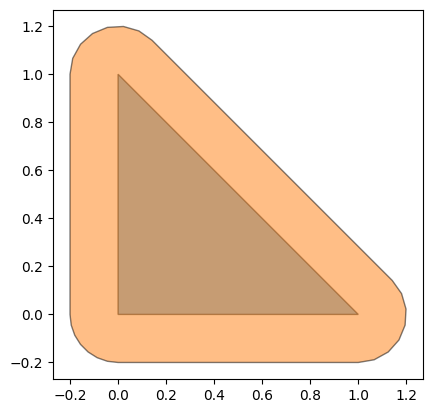

In [812]:
p1 = geometry.Polygon(
    vertices=jnp.array(
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )
)
p2 = mutation.buffer(p1, 0.2)
print(f"{p1.area = }")
print(f"{p2.area = }")

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax)

In [803]:
print(p2.area)

0.87232906


## Test Case: Multiple staircases

In [822]:
p1 = geometry.Polygon(vertices=jnp.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0]]))
p2 = mutation.buffer(p1, 0.2)
p3 = mutation.offset(p2, 1.0, 0.0)
p4 = set_ops.union(p2, p3)
print(f"{p4.area = }")
plotting.plot_polygons(p4)

p4.area = Array(2.4389873, dtype=float32)
